# Drive mounting


In [3]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Step 2: Copy directly from your Drive folder
!mkdir -p ./Images-processed

!cp -r "/content/drive/MyDrive/Images-processed/CT_COVID"    ./Images-processed/CT_COVID
!cp -r "/content/drive/MyDrive/Images-processed/CT_NonCOVID" ./Images-processed/CT_NonCOVID

# Verify
import os
print("CT_COVID    :", len(os.listdir('./Images-processed/CT_COVID')), "files")
print("CT_NonCOVID :", len(os.listdir('./Images-processed/CT_NonCOVID')), "files")

CT_COVID    : 349 files
CT_NonCOVID : 397 files


# Feature Extraction


In [7]:
import os, logging
import numpy as np
import pandas as pd
import SimpleITK as sitk
from PIL import Image                  # ← new: Pillow handles the RGB→grayscale conversion
from radiomics import featureextractor

logging.getLogger("radiomics").setLevel(logging.ERROR)

COVID_DIR     = './Images-processed/CT_COVID'
NON_COVID_DIR = './Images-processed/CT_NonCOVID'

settings = {'enableCExtensions': True}
extractor = featureextractor.RadiomicsFeatureExtractor(**settings)
extractor.disableAllFeatures()
for cls in ['firstorder', 'glcm', 'glrlm', 'glszm', 'gldm']:
    extractor.enableFeatureClassByName(cls)

features_list, labels = [], []

def extract_features(folder_path: str, label_value: int) -> None:
    exts = ('.png', '.jpg', '.jpeg')
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(exts)]
    print(f"Processing {len(files)} files in: {folder_path}")
    succeeded, skipped = 0, 0

    for filename in files:
        filepath = os.path.join(folder_path, filename)
        try:
            # ── FIX: use Pillow to load and force grayscale ──────────────────
            # This handles RGB, RGBA, palette-mode PNGs and JPEGs uniformly.
            pil_img = Image.open(filepath).convert('L')   # 'L' = 8-bit grayscale
            arr_2d  = np.array(pil_img, dtype=np.float32)

            # ── Promote 2D (H,W) → 3D (1,H,W) for PyRadiomics ──────────────
            arr_3d  = arr_2d[np.newaxis, :, :]            # shape: (1, H, W)
            image   = sitk.GetImageFromArray(arr_3d)

            # ── Whole-image mask (all ones, same shape) ───────────────────────
            mask_arr = np.ones(arr_3d.shape, dtype=np.uint8)
            mask     = sitk.GetImageFromArray(mask_arr)
            mask.CopyInformation(image)

            res = extractor.execute(image, mask)
            features_list.append({
                k: float(v) for k, v in res.items()
                if not k.startswith('diagnostics')
            })
            labels.append(label_value)
            succeeded += 1

        except Exception as exc:
            print(f"  [WARN] Skipped {filename}: {exc}")
            skipped += 1

    print(f"  Done — {succeeded} extracted, {skipped} skipped.\n")

extract_features(COVID_DIR,     label_value=1)
extract_features(NON_COVID_DIR, label_value=0)

X = pd.DataFrame(features_list)
y = np.array(labels)
print(f"Extracted {X.shape[0]} samples × {X.shape[1]} features.")
print(f"Class distribution — COVID: {y.sum()}, Non-COVID: {(y==0).sum()}")

Processing 349 files in: ./Images-processed/CT_COVID
  Done — 349 extracted, 0 skipped.

Processing 397 files in: ./Images-processed/CT_NonCOVID
  Done — 397 extracted, 0 skipped.

Extracted 746 samples × 88 features.
Class distribution — COVID: 349, Non-COVID: 397


Train: 596 | Test: 150
  Fold 1 | AUC = 0.9026 | best: {'svm__C': 0.1, 'svm__gamma': 0.01}
  Fold 2 | AUC = 0.8173 | best: {'svm__C': 0.1, 'svm__gamma': 0.01}
  Fold 3 | AUC = 0.8778 | best: {'svm__C': 100, 'svm__gamma': 0.01}
  Fold 4 | AUC = 0.9130 | best: {'svm__C': 0.1, 'svm__gamma': 0.01}
  Fold 5 | AUC = 0.8926 | best: {'svm__C': 0.1, 'svm__gamma': 0.01}

Cross-Validation Mean AUC : 0.8807  (± 0.0337)

Final best hyperparameters : {'svm__C': 0.1, 'svm__gamma': 0.01}

────────────────────────────────────────
  Holdout ROC AUC : 0.8482
  Holdout Accuracy: 0.7867
────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

   Non-COVID       0.82      0.78      0.79        80
       COVID       0.76      0.80      0.78        70

    accuracy                           0.79       150
   macro avg       0.79      0.79      0.79       150
weighted avg       0.79      0.79      0.79       150



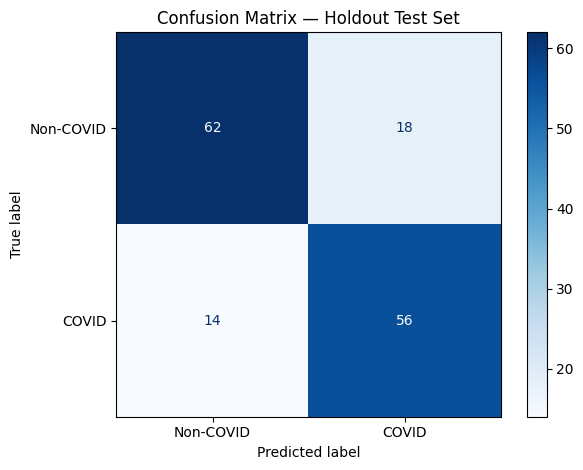


Decision Tree Rules (max_depth=3):
|--- LDA_component_1 <= 0.10
|   |--- LDA_component_1 <= -0.32
|   |   |--- LDA_component_1 <= -0.52
|   |   |   |--- class: 0
|   |   |--- LDA_component_1 >  -0.52
|   |   |   |--- class: 0
|   |--- LDA_component_1 >  -0.32
|   |   |--- LDA_component_1 <= 0.00
|   |   |   |--- class: 1
|   |   |--- LDA_component_1 >  0.00
|   |   |   |--- class: 0
|--- LDA_component_1 >  0.10
|   |--- LDA_component_1 <= 0.71
|   |   |--- LDA_component_1 <= 0.70
|   |   |   |--- class: 1
|   |   |--- LDA_component_1 >  0.70
|   |   |   |--- class: 0
|   |--- LDA_component_1 >  0.71
|   |   |--- LDA_component_1 <= 1.46
|   |   |   |--- class: 1
|   |   |--- LDA_component_1 >  1.46
|   |   |   |--- class: 1


  AI DIAGNOSTIC REPORT  —  Sample #0
  SVM (RBF) Probability : 0.4547
  SVM Decision          : COVID-19 NEGATIVE
  Risk Band             : BORDERLINE — monitor and re-evaluate

  Decision Tree Decision: COVID-19 POSITIVE

  Interpretable Rules (from Decision Tree

In [8]:

from sklearn.model_selection  import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline         import Pipeline
from sklearn.preprocessing    import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm              import SVC
from sklearn.tree             import DecisionTreeClassifier, export_text
from sklearn.metrics          import (roc_auc_score, accuracy_score,
                                      classification_report, confusion_matrix,
                                      ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# ── 1. Imputation & index reset ──────────────────────────────────────────────
#
# FIX 3: reset_index(drop=True) ensures .iloc and numpy array indices
# stay aligned after train_test_split shuffles the rows.
# Without this, `X_train.iloc[tr_idx]` and `y_train[tr_idx]`
# reference different rows — silent data leakage / label mismatch.

if X.isna().any().any():
    X = X.fillna(X.median(numeric_only=True))

X_reset = X.reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_reset, y, test_size=0.20, random_state=42, stratify=y
)
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# ── 2. Stratified K-Fold Cross-Validation (Unit 1) ──────────────────────────
#
# FIX 4: GridSearchCV inside the CV loop covers Unit 2/3
# ("Tuning Model Complexity"). We search over C and gamma,
# the two main complexity knobs for an RBF-SVM.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'svm__C':     [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.001],
}

cv_aucs      = []
cv_best_params = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr,  X_val  = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr,  y_val  = y_train[tr_idx],      y_train[val_idx]

    # Build a Pipeline to guarantee no leakage: every transformer is
    # fit inside GridSearchCV using only the training sub-fold.
    pipe = Pipeline([
        ('scaler_raw', StandardScaler()),
        ('lda',        LinearDiscriminantAnalysis(n_components=1)),
        ('scaler_lda', StandardScaler()),
        ('svm',        SVC(kernel='rbf', probability=True, random_state=42)),
    ])

    grid = GridSearchCV(
        pipe, param_grid,
        cv=3,                       # inner CV for hyperparameter search
        scoring='roc_auc',
        n_jobs=-1,
        refit=True
    )
    grid.fit(X_tr, y_tr)

    fold_auc = roc_auc_score(y_val, grid.predict_proba(X_val)[:, 1])
    cv_aucs.append(fold_auc)
    cv_best_params.append(grid.best_params_)
    print(f"  Fold {fold} | AUC = {fold_auc:.4f} | best: {grid.best_params_}")

# FIX 5: Print the CV mean AUC (was computed but never displayed)
print(f"\nCross-Validation Mean AUC : {np.mean(cv_aucs):.4f}  "
      f"(± {np.std(cv_aucs):.4f})")

# ── 3. Final Model Training ──────────────────────────────────────────────────
#
# Re-run GridSearchCV on the full training set to find the globally
# best hyperparameters, then evaluate on the held-out test set.

final_pipe = Pipeline([
    ('scaler_raw', StandardScaler()),
    ('lda',        LinearDiscriminantAnalysis(n_components=1)),
    ('scaler_lda', StandardScaler()),
    ('svm',        SVC(kernel='rbf', probability=True, random_state=42)),
])

final_grid = GridSearchCV(
    final_pipe, param_grid,
    cv=skf, scoring='roc_auc',
    n_jobs=-1, refit=True
)
final_grid.fit(X_train, y_train)

print(f"\nFinal best hyperparameters : {final_grid.best_params_}")

# ── 4. Decision Tree Explainer (trained on same transformed space) ───────────
#
# We must transform X_train through the same fitted pipeline steps
# to get the 1-D LDA representation the tree will learn from.
# Using named_steps gives us access to each fitted transformer.

best_pipe    = final_grid.best_estimator_
scaler_raw   = best_pipe.named_steps['scaler_raw']
lda_fitted   = best_pipe.named_steps['lda']
scaler_lda   = best_pipe.named_steps['scaler_lda']

def transform_to_lda(X_df):
    """Apply the three preprocessing steps to any DataFrame."""
    return scaler_lda.transform(
               lda_fitted.transform(
                   scaler_raw.transform(X_df)))

X_train_lda = transform_to_lda(X_train)
X_test_lda  = transform_to_lda(X_test)

tree_final = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_final.fit(X_train_lda, y_train)

# ── 5. Evaluation (Unit 1: ROC AUC, Accuracy, Confusion Matrix) ─────────────
y_test_prob = final_grid.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, y_test_prob)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n{'─'*40}")
print(f"  Holdout ROC AUC : {test_auc:.4f}")
print(f"  Holdout Accuracy: {test_acc:.4f}")
print(f"{'─'*40}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred,
                             target_names=['Non-COVID', 'COVID']))

# FIX 6: Confusion matrix was required by Unit 1 but never printed
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Non-COVID', 'COVID'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Holdout Test Set")
plt.tight_layout()
plt.show()

# ── 6. Decision Tree Rules ───────────────────────────────────────────────────
tree_rules = export_text(tree_final, feature_names=['LDA_component_1'])
print("\nDecision Tree Rules (max_depth=3):")
print(tree_rules)

# ── 7. AI Diagnostic Report Generator ───────────────────────────────────────
#
# FIX 7: tree_pred is now used in the report. Risk band added.
# A sample is taken from the test set for demonstration.

def generate_report(sample_df: pd.DataFrame, sample_index: int = 0) -> str:
    """
    Generate a diagnostic report for one sample.

    Parameters
    ----------
    sample_df    : a single-row DataFrame with the same columns as X.
    sample_index : used only for display labelling.
    """
    x_lda = transform_to_lda(sample_df)

    prob      = final_grid.best_estimator_.named_steps['svm'].predict_proba(x_lda)[0, 1]
    tree_pred = tree_final.predict(x_lda)[0]

    # Risk band (interpretability layer for the report)
    if prob >= 0.75:
        risk = "HIGH — recommend clinical follow-up"
    elif prob >= 0.45:
        risk = "BORDERLINE — monitor and re-evaluate"
    else:
        risk = "LOW — no strong COVID-19 signal detected"

    svm_label  = "COVID-19 POSITIVE"  if prob >= 0.5 else "COVID-19 NEGATIVE"
    tree_label = "COVID-19 POSITIVE"  if tree_pred == 1 else "COVID-19 NEGATIVE"

    report = (
        f"\n{'='*50}\n"
        f"  AI DIAGNOSTIC REPORT  —  Sample #{sample_index}\n"
        f"{'='*50}\n"
        f"  SVM (RBF) Probability : {prob:.4f}\n"
        f"  SVM Decision          : {svm_label}\n"
        f"  Risk Band             : {risk}\n"
        f"\n  Decision Tree Decision: {tree_label}\n"
        f"\n  Interpretable Rules (from Decision Tree):\n"
        f"{tree_rules}"
        f"\n  Model Performance     : Holdout ROC AUC = {test_auc:.4f}\n"
        f"{'='*50}\n"
    )
    return report

# ── Demo: report for the first test sample ───────────────────────────────────
sample = X_test.iloc[[0]]   # keep as DataFrame (double brackets)
print(generate_report(sample, sample_index=0))